In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ***1️⃣ Import & Load Dataset***

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# ***2️⃣ SIMPLE LINEAR REGRESSION***


---
* Gunakan 1 fitur: MedInc (Median Income)









In [3]:
X = df[["MedInc"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

**📊 Visualisasi Garis Regresi**

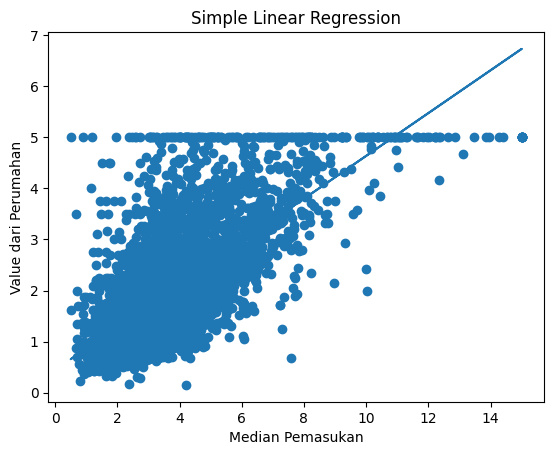

In [5]:
plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_simple)
plt.title("Simple Linear Regression")
plt.xlabel("Median Pemasukan")
plt.ylabel("Value dari Perumahan")
plt.show()

**📈 Evaluasi Simple Regression**

In [6]:
mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression")
print("MAE:", mae_simple)
print("RMSE:", rmse_simple)
print("R2:", r2_simple)

Simple Linear Regression
MAE: 0.629908653009376
RMSE: 0.8420901241414455
R2: 0.45885918903846656


# **✅ 3️⃣ MULTIPLE LINEAR REGRESSION (≥3 fitur)**



---


> Gunakan 4 Fitur :
*   MedINC
*   HouseAge
*   AveRooms
*   Population

In [7]:
features = ["MedInc", "HouseAge", "AveRooms", "Population"]

X_multi = df[features]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

**📈 Evaluasi Multiple Regression**

In [8]:
mae_multi = mean_absolute_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("Multiple Linear Regression")
print("MAE:", mae_multi)
print("RMSE:", rmse_multi)
print("R2:", r2_multi)

Multiple Linear Regression
MAE: 0.6024695935335578
RMSE: 0.8110484374335526
R2: 0.4980196421223846


# ***✅ 4️⃣ Polynomial Regression (Degree 1 vs Degree 2)***


---

1 fitur supaya visualnya jelas (MedInc).

**🔹 Degree 1 (Linear)**

In [9]:
poly1 = PolynomialFeatures(degree=1)
X_poly1 = poly1.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly1, y, test_size=0.2, random_state=42)

model_poly1 = LinearRegression()
model_poly1.fit(X_train, y_train)

y_pred_poly1 = model_poly1.predict(X_test)

**🔹 Degree 2 (Quadratic)**

In [10]:
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly2, y, test_size=0.2, random_state=42)

model_poly2 = LinearRegression()
model_poly2.fit(X_train, y_train)

y_pred_poly2 = model_poly2.predict(X_test)

# 📊 Visualisasi Perbandingan

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


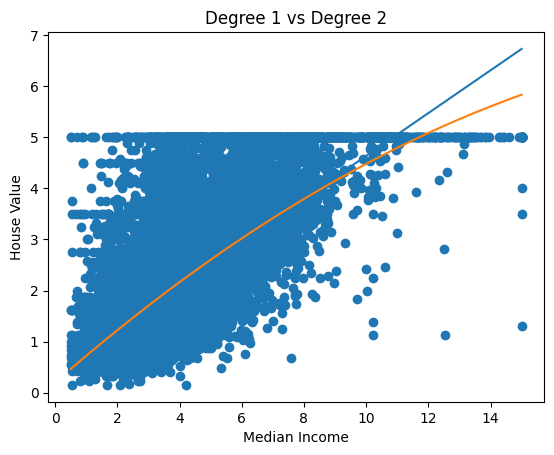

In [11]:
plt.figure()
plt.scatter(df["MedInc"], y)

# Sort biar garis rapi
sorted_idx = np.argsort(df["MedInc"])
X_sorted = df["MedInc"].values[sorted_idx].reshape(-1,1)

plt.plot(X_sorted, model_poly1.predict(poly1.transform(X_sorted)))
plt.plot(X_sorted, model_poly2.predict(poly2.transform(X_sorted)))

plt.title("Degree 1 vs Degree 2")
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.show()

**📈 Evaluasi Degree 1 vs Degree 2**

In [12]:
print("Degree 1 R2:", r2_score(y_test, y_pred_poly1))
print("Degree 2 R2:", r2_score(y_test, y_pred_poly2))

Degree 1 R2: 0.45885918903846645
Degree 2 R2: 0.46331772769346236


# 📊 Kesimpulan

Secara umum:



---



Multiple Linear Regression > Simple Linear Regression
(karena lebih banyak informasi fitur)

Polynomial Degree 2 sering memiliki R² lebih tinggi dibanding Degree 1
karena bisa menangkap hubungan non-linear

Namun:

Degree 2 bisa overfitting jika data kecil

Degree 1 lebih stabil & interpretatif

In [14]:
import os
os.chdir("/content/drive/MyDrive/ml-practicum")
print(os.getcwd())

/content/drive/MyDrive/ml-practicum
